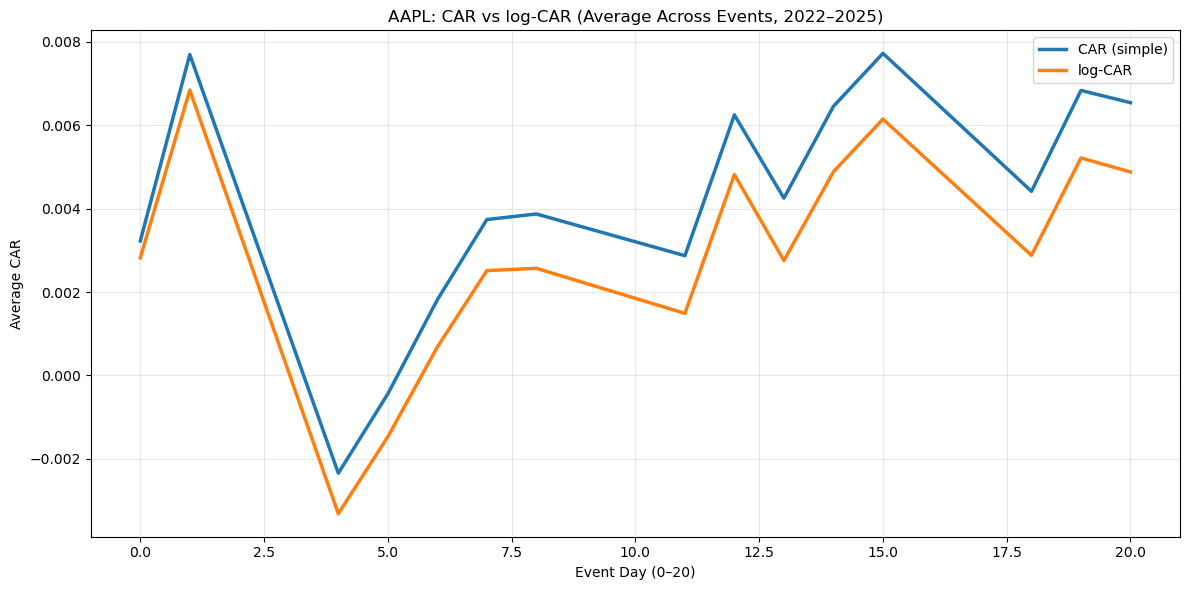

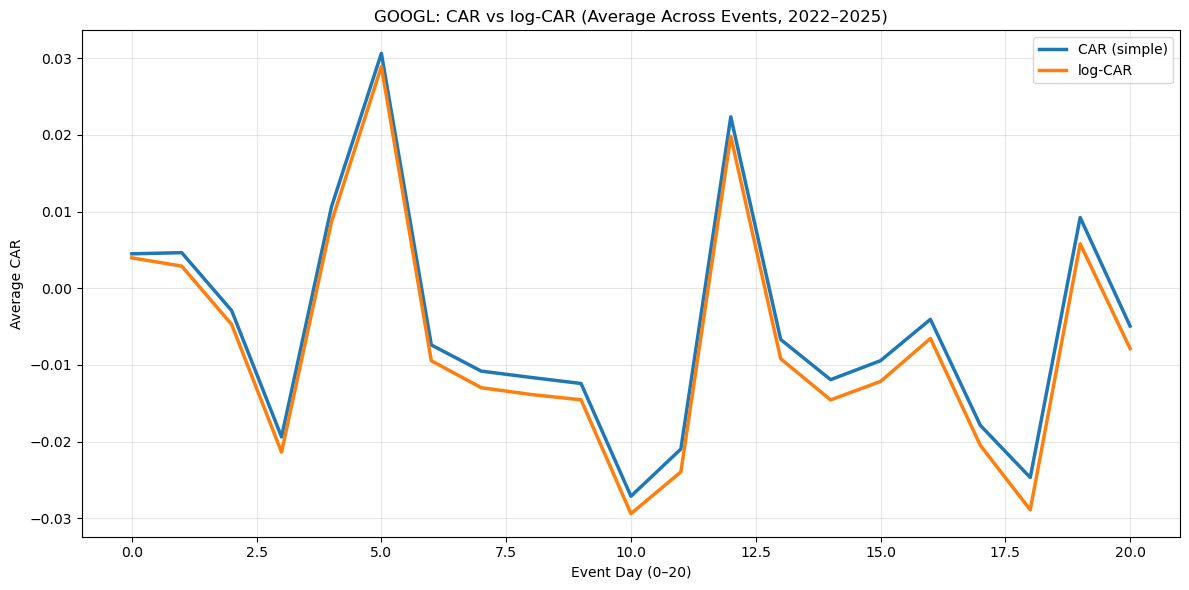

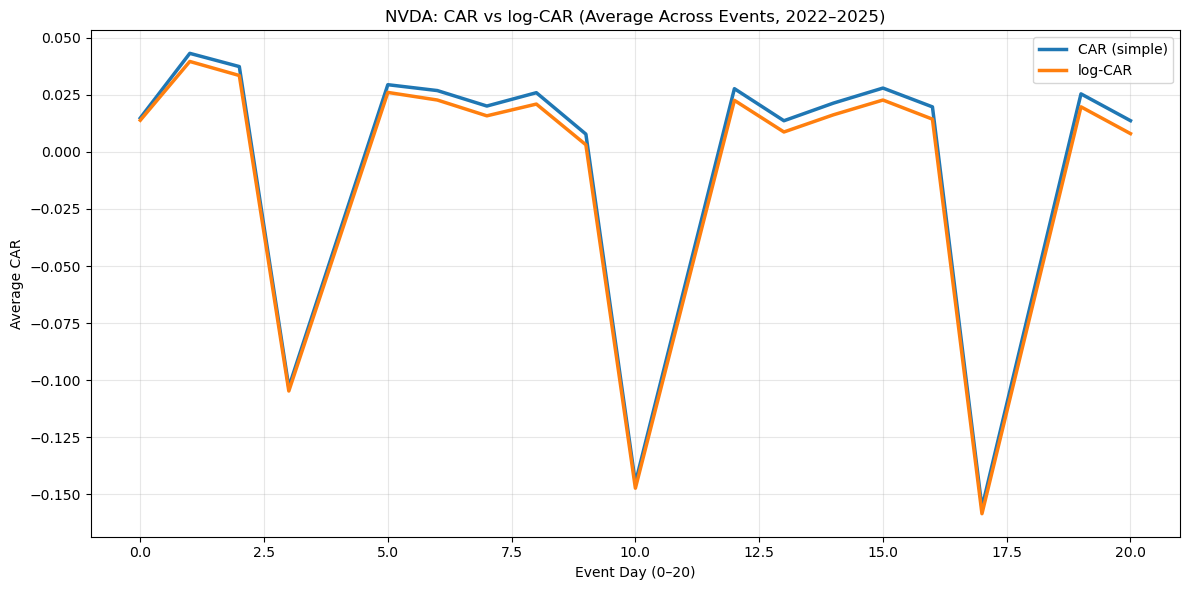

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/merged_event_panel_sub.csv")
df = df.sort_values(["event_id", "event_day"])

# 2. Filter to 2022–2025
df["reportedDate"] = pd.to_datetime(df["reportedDate"])
df = df[(df["reportedDate"].dt.year >= 2022) & (df["reportedDate"].dt.year <= 2025)]


# 3. Compute CAR (simple cumulative abnormal return)
df["CAR"] = df.groupby("event_id")["abnormal_return"].cumsum()

# 4. Compute log‑CAR
df["log_AR"] = np.log1p(df["abnormal_return"])     # log(1 + AR)
df["log_CAR"] = df.groupby("event_id")["log_AR"].cumsum()


# 5. Keep only event window 0–20
df_0_20 = df[(df["event_day"] >= 0) & (df["event_day"] <= 20)].copy()

# 6. Function to plot CAR vs log‑CAR for one company
def plot_car_vs_logcar(df, ticker):
    df_t = df[df["ticker"] == ticker].copy()
    
    # Average across events for each event_day
    df_avg = (
        df_t.groupby("event_day")[["CAR", "log_CAR"]]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=df_avg, x="event_day", y="CAR", label="CAR (simple)", linewidth=2.5)
    sns.lineplot(data=df_avg, x="event_day", y="log_CAR", label="log-CAR", linewidth=2.5)
    
    plt.title(f"{ticker}: CAR vs log-CAR (Average Across Events, 2022–2025)")
    plt.xlabel("Event Day (0–20)")
    plt.ylabel("Average CAR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7. Run the plots
plot_car_vs_logcar(df_0_20, "AAPL")
plot_car_vs_logcar(df_0_20, "GOOGL")
plot_car_vs_logcar(df_0_20, "NVDA")

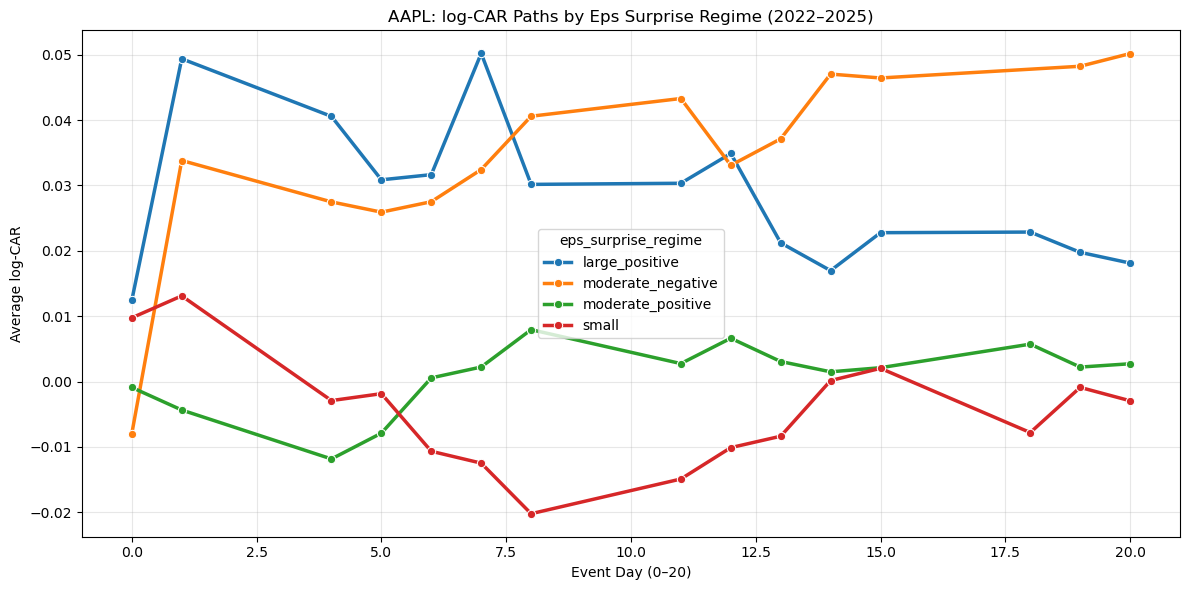

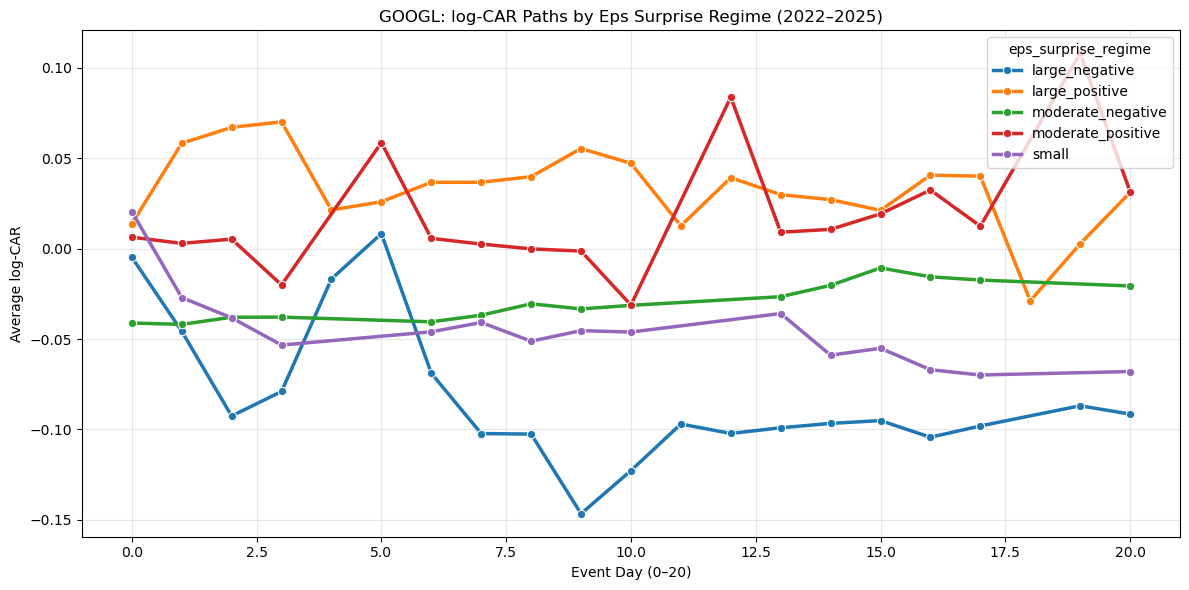

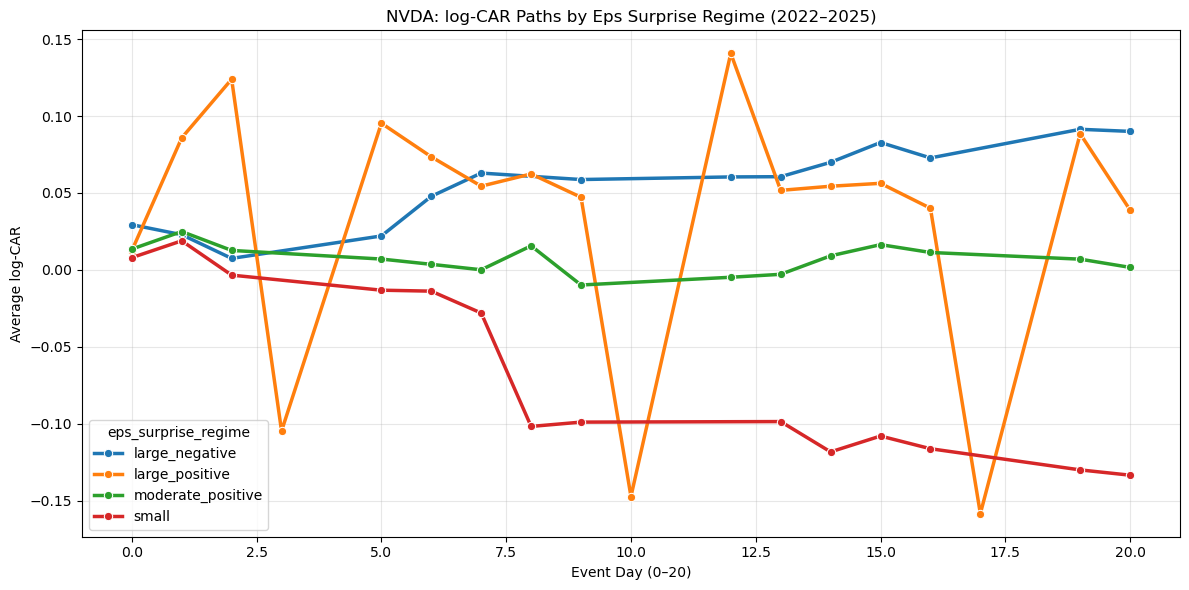

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/merged_event_panel_sub.csv")
df = df.sort_values(["event_id", "event_day"])

# 2. Filter to 2022–2025
df["reportedDate"] = pd.to_datetime(df["reportedDate"])
df = df[(df["reportedDate"].dt.year >= 2022) & (df["reportedDate"].dt.year <= 2025)]

# 3. Compute CAR (simple cumulative abnormal return)
df["CAR"] = df.groupby("event_id")["abnormal_return"].cumsum()

# 4. Compute log‑CAR
df["log_AR"] = np.log1p(df["abnormal_return"])     # log(1 + AR)
df["log_CAR"] = df.groupby("event_id")["log_AR"].cumsum()

# 5. Keep only event window 0–20
df_0_20 = df[(df["event_day"] >= 0) & (df["event_day"] <= 20)].copy()

# 6. Function to plot log‑CAR paths by regime for one company
def plot_logcar_paths(df, ticker, regime_col):
    df_t = df[df["ticker"] == ticker].copy()
    
    # Average log-CAR per event_day per regime
    df_avg = (
        df_t.groupby([regime_col, "event_day"])["log_CAR"]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_avg,
        x="event_day",
        y="log_CAR",
        hue=regime_col,
        linewidth=2.5,
        marker="o"
    )
    
    plt.title(f"{ticker}: log-CAR Paths by {regime_col.replace('_', ' ').title()} (2022–2025)")
    plt.xlabel("Event Day (0–20)")
    plt.ylabel("Average log-CAR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7. Run the plots
plot_logcar_paths(df_0_20, "AAPL", "eps_surprise_regime")
plot_logcar_paths(df_0_20, "GOOGL", "eps_surprise_regime")
plot_logcar_paths(df_0_20, "NVDA", "eps_surprise_regime")

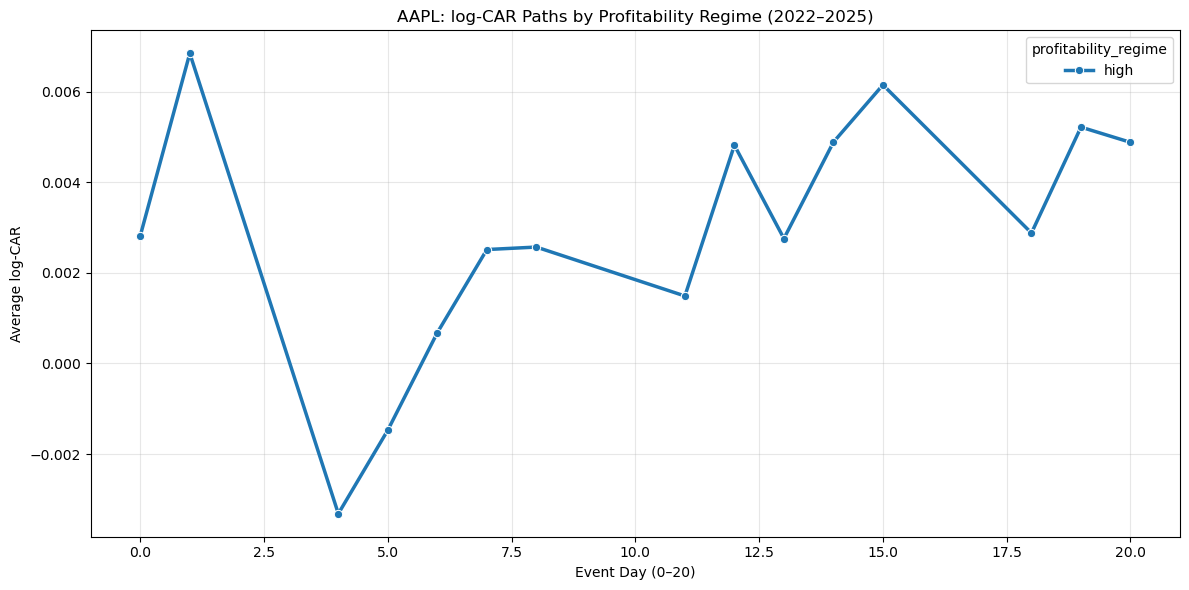

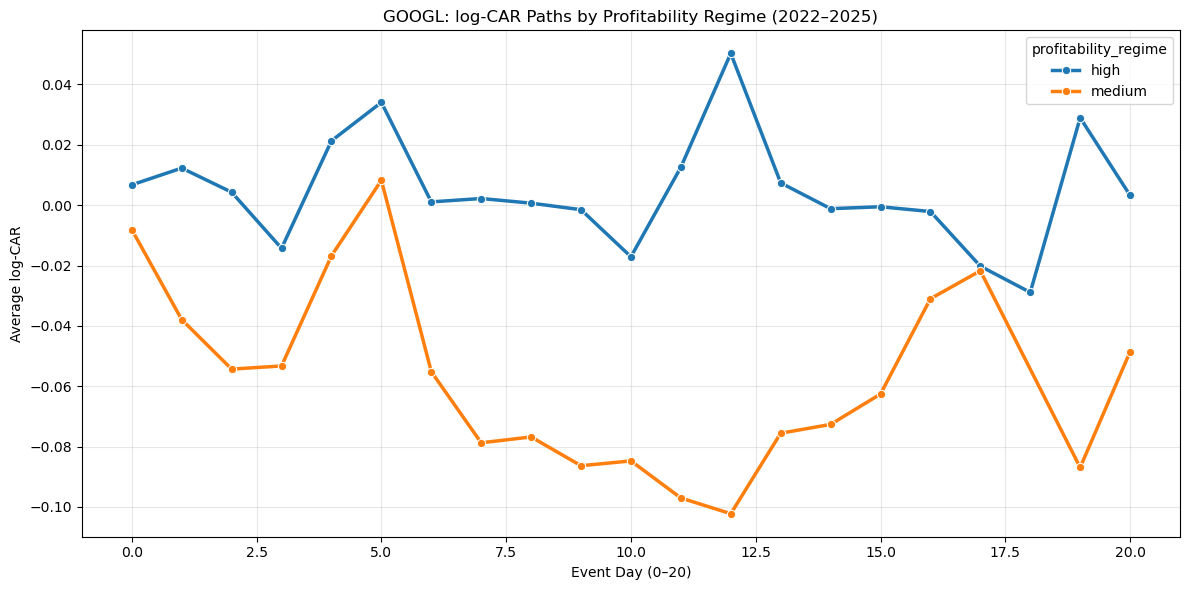

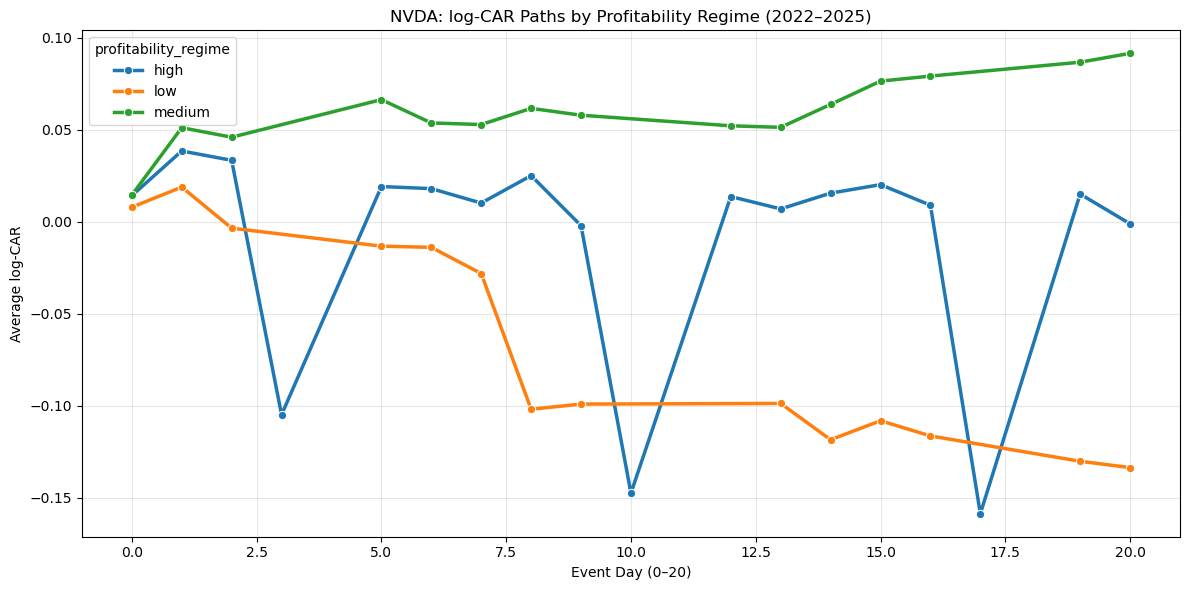

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/merged_event_panel_sub.csv")
df = df.sort_values(["event_id", "event_day"])


# 2. Filter to 2022–2025
df["reportedDate"] = pd.to_datetime(df["reportedDate"])
df = df[(df["reportedDate"].dt.year >= 2022) & (df["reportedDate"].dt.year <= 2025)]

# 3. Compute CAR (simple cumulative abnormal return)
df["CAR"] = df.groupby("event_id")["abnormal_return"].cumsum()


# 4. Compute log‑CAR
df["log_AR"] = np.log1p(df["abnormal_return"])     # log(1 + AR)
df["log_CAR"] = df.groupby("event_id")["log_AR"].cumsum()


# 5. Keep only event window 0–20
df_0_20 = df[(df["event_day"] >= 0) & (df["event_day"] <= 20)].copy()


# 6. Function to plot log‑CAR paths by profitability regime
def plot_logcar_profitability(df, ticker):
    df_t = df[df["ticker"] == ticker].copy()
    
    # Average log-CAR per event_day per profitability regime
    df_avg = (
        df_t.groupby(["profitability_regime", "event_day"])["log_CAR"]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_avg,
        x="event_day",
        y="log_CAR",
        hue="profitability_regime",
        linewidth=2.5,
        marker="o"
    )
    
    plt.title(f"{ticker}: log-CAR Paths by Profitability Regime (2022–2025)")
    plt.xlabel("Event Day (0–20)")
    plt.ylabel("Average log-CAR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7. Run the plots
plot_logcar_profitability(df_0_20, "AAPL")
plot_logcar_profitability(df_0_20, "GOOGL")
plot_logcar_profitability(df_0_20, "NVDA")

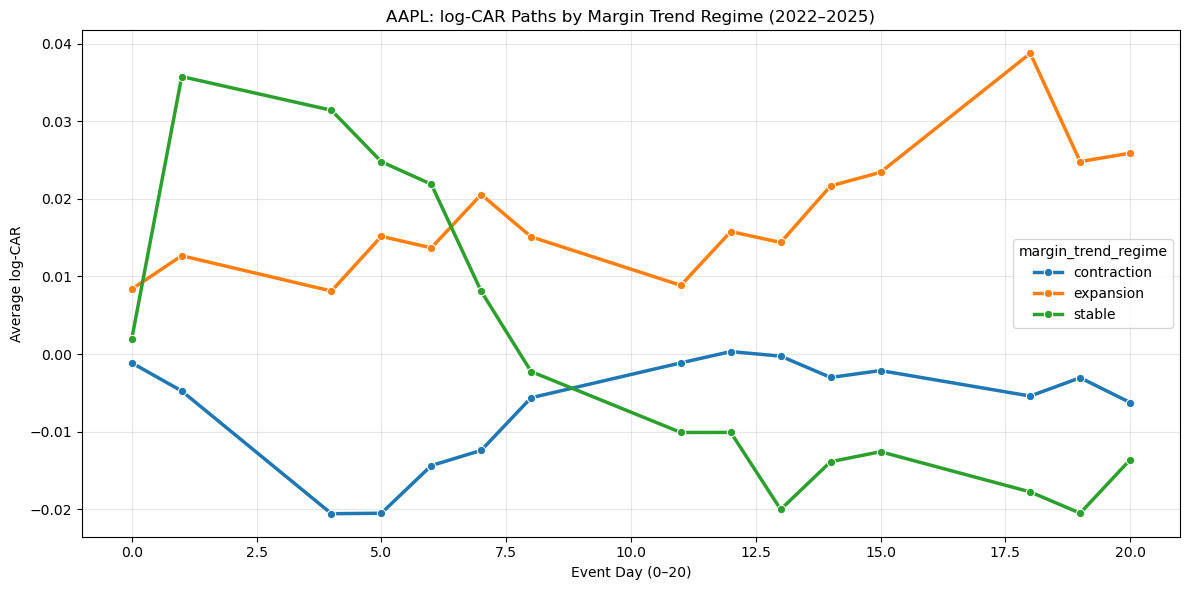

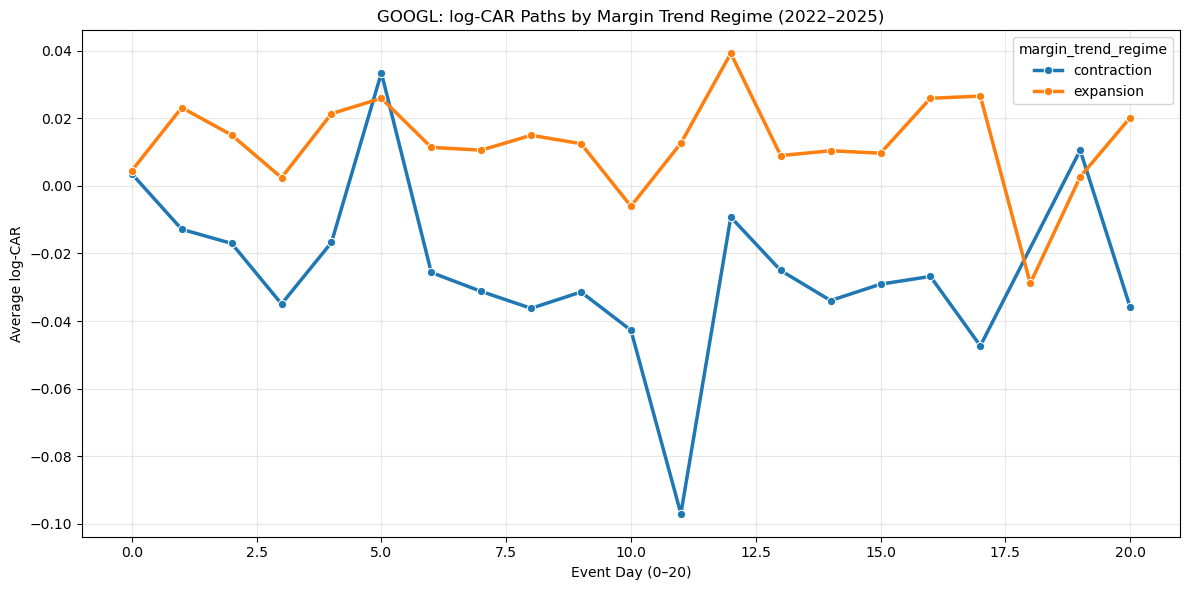

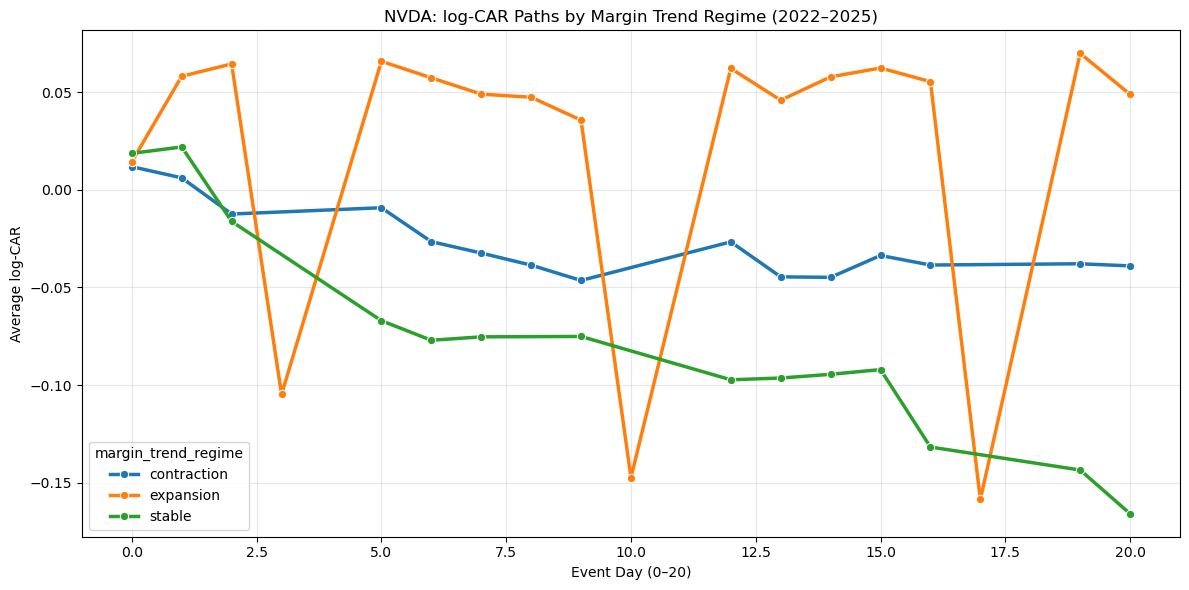

In [17]:

# ---------------------------------------------------------
# 6. Function to plot log‑CAR paths by margin trend regime
# ---------------------------------------------------------
def plot_logcar_margin(df, ticker):
    df_t = df[df["ticker"] == ticker].copy()
    
    # Average log-CAR per event_day per margin trend regime
    df_avg = (
        df_t.groupby(["margin_trend_regime", "event_day"])["log_CAR"]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_avg,
        x="event_day",
        y="log_CAR",
        hue="margin_trend_regime",
        linewidth=2.5,
        marker="o"
    )
    
    plt.title(f"{ticker}: log-CAR Paths by Margin Trend Regime (2022–2025)")
    plt.xlabel("Event Day (0–20)")
    plt.ylabel("Average log-CAR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7. Run the plots
plot_logcar_margin(df_0_20, "AAPL")
plot_logcar_margin(df_0_20, "GOOGL")
plot_logcar_margin(df_0_20, "NVDA")